# EMS predictive relocation — the real-data pipeline, visualized

Companion to `visualize.ipynb`. That notebook explores an **invented** fleet and an
**invented** response-time generator on Montgomery County calls. This one plots only
what lives in `data/`: real call feeds, real OSRM road-network routing, and the
outputs of the MEXCLP static-vs-dynamic simulation.

## What is real and what is assumed

| Layer | Source |
|---|---|
| Seattle call location, timestamp, type | **Real** — data.seattle.gov `kzjm-xkqj`, most recent 500k rows |
| Cincinnati call location, timestamp, type | **Real** — data.cincinnati-oh.gov `vnsz-a3wp`, 60-day window |
| Cincinnati measured response times | **Real** — `create_time_incident` → `arrival_time_primary_unit` |
| Zone centers, candidate posts | Derived — k-means on real call density |
| Travel time between any two points | **Real** — OSRM driving durations, precomputed |
| Per-call unit-busy time (dispatch → clear) | **Assumed** — lognormal around 50 min, the one non-real input |
| Fleet size and positions | Hypothetical — sized to real peak-hour offered load |

Sections 6–8 compare two dispatch strategies over the *identical* real call stream,
so the static-vs-dynamic difference is a paired comparison. Absolute minutes still
inherit the 50-minute service-time assumption; the comparison between strategies
does not depend on it.

Same plot grammar as `visualize.ipynb`: one theme block, `finish()` for titles and
grid, sequential ramp for magnitude, diverging for polarity, at most three
categorical slots on any map.

## 1 · Setup

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())
DATA = ROOT / "data"
CINCY = DATA / "cincinnati"

# Filters used by the pipeline scripts - kept identical so the plots below
# describe the same call sets the simulation ran on.
SEATTLE_EMS_TYPES = ["Aid Response", "Medic Response", "Low Acuity", "Triaged Incident",
                     "Nurseline", "MVI", "Automatic Medical Alarm"]
SEATTLE_BBOX = dict(lat=(47.4, 47.8), lng=(-122.5, -122.2))

RESPONSE_STANDARD_MIN = 8     # the coverage standard MEXCLP is built around
print(ROOT)

/home/red/Documents/GitHub/ems-relocation


### Plot theme

Copied verbatim from `visualize.ipynb` so the two notebooks render as one document.

In [2]:
THEME = "light"   # "light" or "dark"

PALETTES = {
    "light": dict(
        surface="#fcfcfb", ink="#0b0b0b", ink2="#52514e", ink3="#87857d",
        grid="#e6e5e1",
        cat=["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
             "#008300", "#4a3aa7", "#e34948"],
        seq=["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
        div_lo="#2a78d6", div_mid="#f0efec", div_hi="#e34948",
    ),
    "dark": dict(
        surface="#1a1a19", ink="#ffffff", ink2="#c3c2b7", ink3="#8d8b80",
        grid="#333331",
        cat=["#3987e5", "#d95926", "#199e70", "#c98500", "#d55181",
             "#008300", "#9085e9", "#e66767"],
        seq=["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
        div_lo="#3987e5", div_mid="#383835", div_hi="#e66767",
    ),
}
P = PALETTES[THEME]
CAT = P["cat"]

SEQ = mpl.colors.LinearSegmentedColormap.from_list("seq_blue", P["seq"])
DIV = mpl.colors.LinearSegmentedColormap.from_list("div_br", [P["div_lo"], P["div_mid"], P["div_hi"]])

mpl.rcParams.update({
    "figure.facecolor": P["surface"], "axes.facecolor": P["surface"],
    "savefig.facecolor": P["surface"], "figure.dpi": 110,
    "text.color": P["ink"], "axes.labelcolor": P["ink2"],
    "xtick.color": P["ink2"], "ytick.color": P["ink2"],
    "axes.edgecolor": P["grid"], "grid.color": P["grid"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.8, "grid.linewidth": 0.6, "grid.linestyle": "-",
    "lines.linewidth": 2.0, "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 12, "legend.frameon": False, "figure.autolayout": False,
})


def finish(ax, title=None, sub=None, grid="y"):
    """Title, subtitle and a recessive grid on one axis."""
    if title:
        ax.set_title(title, color=P["ink"], pad=24 if sub else 10)
    if sub:
        # offset in points, so it clears the title at any figure height
        ax.annotate(sub, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 6), textcoords="offset points",
                    color=P["ink3"], fontsize=9, va="bottom")
    if grid:
        ax.grid(axis=grid, alpha=0.9)
        ax.set_axisbelow(True)
    return ax

## 2 · Load the real call feeds

In [3]:
DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


def add_time_parts(df, ts="datetime"):
    t = df[ts]
    df["hour"] = t.dt.hour
    df["dow"] = t.dt.dayofweek          # 0 = Monday
    df["date"] = t.dt.normalize()
    return df


# Seattle - same type filter and bounding box as pipeline_seattle.py
sea = pd.read_csv(DATA / "seattle" / "seattle_911_raw.csv",
                  usecols=["type", "datetime", "latitude", "longitude", "address"])
sea = sea[sea["type"].str.contains("|".join(SEATTLE_EMS_TYPES), case=False, na=False)]
sea = sea.dropna(subset=["latitude", "longitude", "datetime"])
sea = sea[sea["latitude"].between(*SEATTLE_BBOX["lat"])
          & sea["longitude"].between(*SEATTLE_BBOX["lng"])].copy()
sea["datetime"] = pd.to_datetime(sea["datetime"], errors="coerce")
sea = add_time_parts(sea.dropna(subset=["datetime"]).reset_index(drop=True))

# Cincinnati - the committed 60-day EMS sample the routing matrices were built on
cin = pd.read_csv(CINCY / "calls_60d.csv", parse_dates=["datetime"])
cin = add_time_parts(cin)

for name, df in [("Seattle", sea), ("Cincinnati", cin)]:
    span = f"{df.datetime.min():%b %d %Y} - {df.datetime.max():%b %d %Y}"
    print(f"{name:12s} {len(df):>7,} EMS calls  {span}  "
          f"{len(df) / df['date'].nunique():.0f}/day")

Seattle      380,604 EMS calls  Jul 02 2022 - Jul 25 2026  256/day
Cincinnati    10,749 EMS calls  May 24 2026 - Jul 23 2026  176/day


In [4]:
# Everything downstream reads from these files. Load once, plot many.
sim_sea = json.loads((DATA / "dynamic_sim_seattle.json").read_text())
sim_cin = json.loads((CINCY / "dynamic_sim_cincinnati.json").read_text())
trace = json.loads((DATA / "sim_trace_seattle.json").read_text())
forecast = json.loads((DATA / "demand_forecast.json").read_text())
reloc_montco = json.loads((DATA / "relocation_model.json").read_text())
reloc_sea = json.loads((DATA / "relocation_model_seattle.json").read_text())

zz_sea = np.load(DATA / "osrm_zone_zone_duration_sec.npy") / 60      # minutes
zc_sea = np.load(DATA / "osrm_zone_call_duration_sec.npy") / 60
zz_cin = np.load(CINCY / "osrm_zone_zone_duration_sec.npy") / 60
zc_cin = np.load(CINCY / "osrm_zone_call_duration_sec.npy") / 60

print(f"Seattle    zone-zone {zz_sea.shape}  zone-call {zc_sea.shape}")
print(f"Cincinnati zone-zone {zz_cin.shape}  zone-call {zc_cin.shape}")
print(f"routing: {sim_sea['routing_source']}")

Seattle    zone-zone (20, 20)  zone-call (20, 14070)
Cincinnati zone-zone (20, 20)  zone-call (20, 10749)
routing: OSRM public demo server, real driving durations (no flat-mph assumption)


## 3 · What the real calls look like

Same four questions as the companion notebook — *when*, *what*, *where*, and how
concentrated — but on two real cities instead of one.

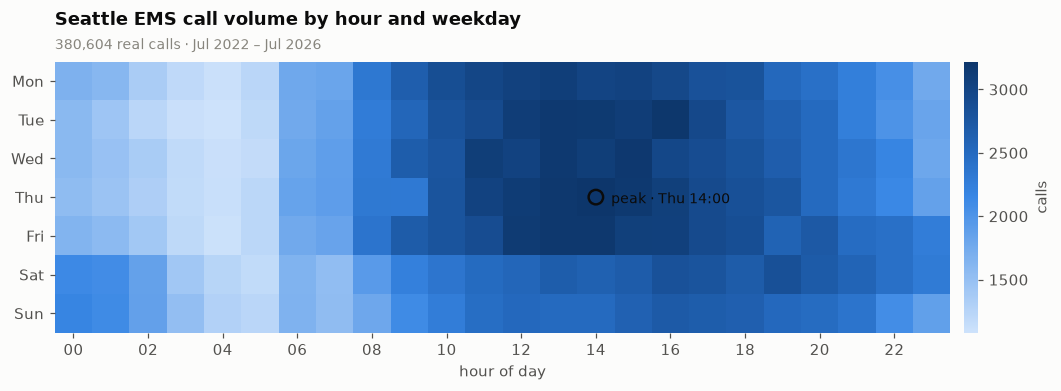

In [5]:
# When - hour x weekday. Magnitude on an ordered grid => single-hue sequential.
grid = (sea.groupby(["dow", "hour"]).size()
        .unstack(fill_value=0)
        .reindex(index=range(7), columns=range(24), fill_value=0))

fig, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(grid.values, cmap=SEQ, aspect="auto", origin="upper")
ax.set_xticks(range(0, 24, 2), [f"{h:02d}" for h in range(0, 24, 2)])
ax.set_yticks(range(7), DOW)
ax.set_xlabel("hour of day")
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.03)
cb.set_label("calls", color=P["ink2"])
cb.outline.set_visible(False)

peak = grid.stack().idxmax()
ax.scatter([peak[1]], [peak[0]], s=90, facecolors="none",
           edgecolors=P["ink"], linewidths=1.6)
ax.annotate(f"peak · {DOW[peak[0]]} {peak[1]:02d}:00",
            (peak[1], peak[0]), textcoords="offset points", xytext=(10, -4),
            color=P["ink"], fontsize=9)
span_sea = f"{sea.datetime.min():%b %Y} – {sea.datetime.max():%b %Y}"
finish(ax, "Seattle EMS call volume by hour and weekday",
       f"{len(sea):,} real calls · {span_sea}", grid=None)
plt.show()

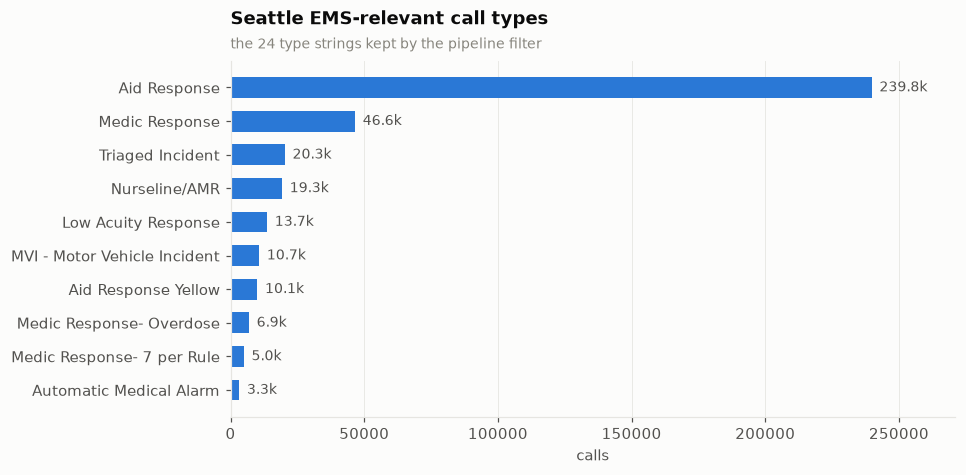

In [6]:
# What - one series, one color. Ranked, so length carries the magnitude.
top_type = sea["type"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.barh(top_type.index, top_type.values, color=CAT[0], height=0.62)
ax.bar_label(ax.containers[0], labels=[f"{v/1000:.1f}k" for v in top_type.values],
             padding=5, color=P["ink2"], fontsize=9)
ax.set_xlim(0, top_type.max() * 1.13)
ax.set_xlabel("calls")
finish(ax, "Seattle EMS-relevant call types",
       f"the {sea['type'].nunique()} type strings kept by the pipeline filter", grid="x")
plt.show()

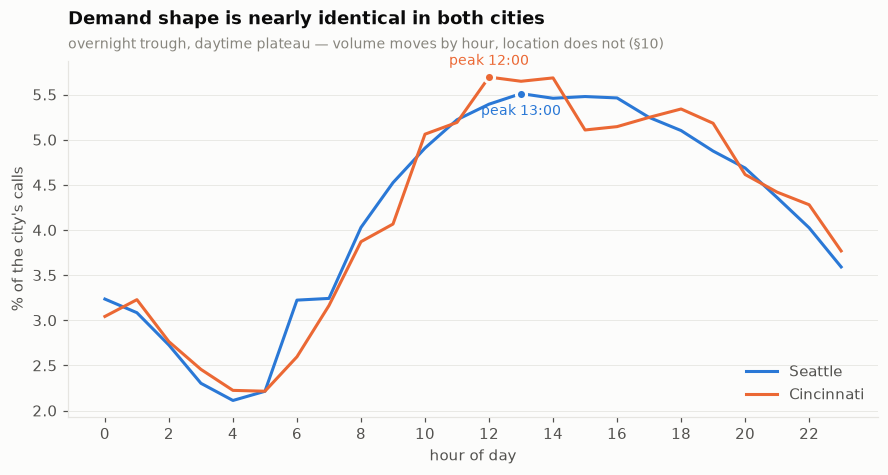

In [7]:
# Two cities, one quantity (share of a day's calls) => one axis, two series.
prof = pd.DataFrame({
    "Seattle": sea.groupby("hour").size() / len(sea),
    "Cincinnati": cin.groupby("hour").size() / len(cin),
}).reindex(range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
for (col, color, dy) in [("Seattle", CAT[0], -14), ("Cincinnati", CAT[1], 8)]:
    ax.plot(prof.index, prof[col] * 100, color=color, label=col)
    h = prof[col].idxmax()
    ax.scatter([h], [prof[col][h] * 100], s=44, color=color,
               edgecolors=P["surface"], linewidths=2, zorder=3)
    ax.annotate(f"peak {h:02d}:00", (h, prof[col][h] * 100), xytext=(0, dy),
                textcoords="offset points", ha="center", color=color, fontsize=9)
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("hour of day"); ax.set_ylabel("% of the city's calls")
ax.legend(loc="lower right", labelcolor=P["ink2"])
finish(ax, "Demand shape is nearly identical in both cities",
       "overnight trough, daytime plateau — volume moves by hour, location does not (§10)")
plt.show()

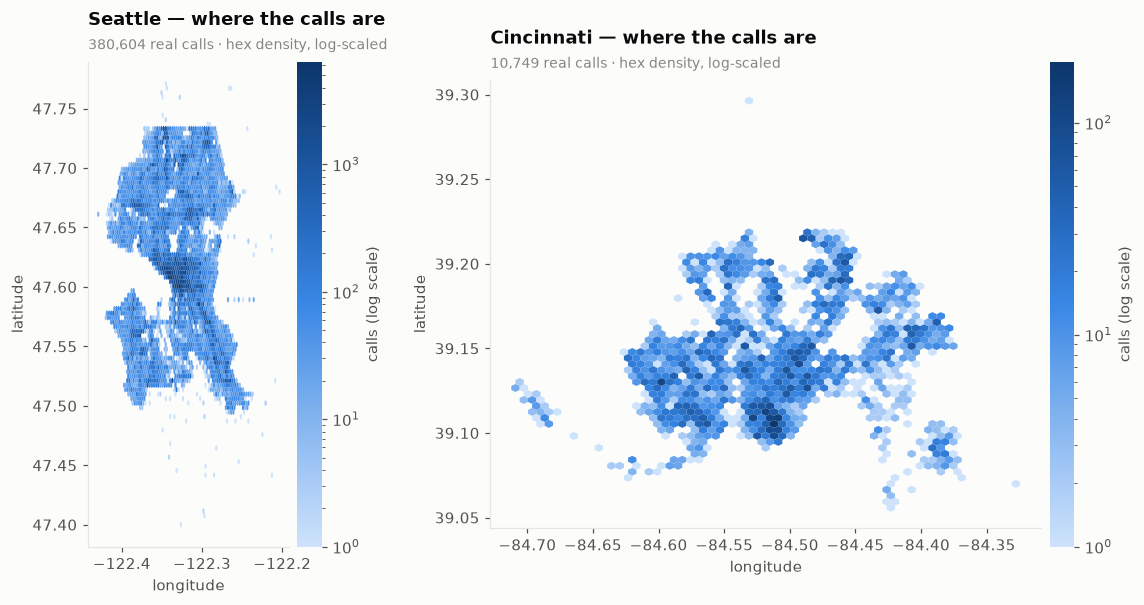

In [8]:
# Geography - continuous density, so the sequential ramp again.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
for ax, (name, df, lat0, gs) in zip(axes, [("Seattle", sea, 47.6, 85), ("Cincinnati", cin, 39.14, 60)]):
    lng = df["longitude"]; lat = df["latitude"]
    hb = ax.hexbin(lng, lat, gridsize=gs, cmap=SEQ, bins="log", mincnt=1, linewidths=0)
    ax.set_aspect(1 / np.cos(np.radians(lat0)))
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    cb = fig.colorbar(hb, ax=ax, pad=0.015, fraction=0.045)
    cb.set_label("calls (log scale)", color=P["ink2"])
    cb.outline.set_visible(False)
    finish(ax, f"{name} — where the calls are",
           f"{len(df):,} real calls · hex density, log-scaled", grid=None)
plt.tight_layout()
plt.show()

## 4 · Real road-network routing

Every travel time in the simulation is an OSRM driving duration, precomputed once:
a zone-to-zone matrix for repositioning, and a zone-to-every-real-call matrix for
dispatch. No haversine, no flat mph.

The second plot is the one that matters for post placement — given the candidate
posts, what share of real calls sits within *t* minutes of the nearest one. That
curve at t = 8 min is the coverage MEXCLP is maximizing.

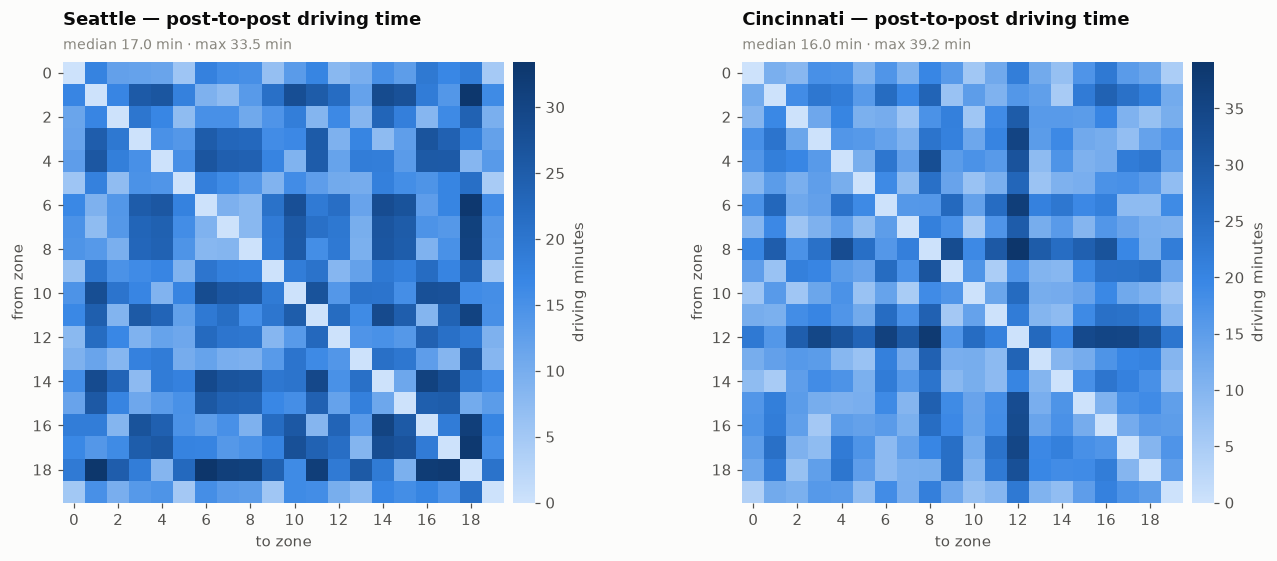

In [9]:
# Repositioning cost between candidate posts. Ordered pairs, magnitude => sequential.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
for ax, (name, m) in zip(axes, [("Seattle", zz_sea), ("Cincinnati", zz_cin)]):
    im = ax.imshow(m, cmap=SEQ, origin="upper")
    ax.set_xlabel("to zone"); ax.set_ylabel("from zone")
    ax.set_xticks(range(0, len(m), 2)); ax.set_yticks(range(0, len(m), 2))
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
    cb = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.045)
    cb.set_label("driving minutes", color=P["ink2"])
    cb.outline.set_visible(False)
    off = m[~np.eye(len(m), dtype=bool)]
    finish(ax, f"{name} — post-to-post driving time",
           f"median {np.median(off):.1f} min · max {off.max():.1f} min", grid=None)
plt.tight_layout()
plt.show()

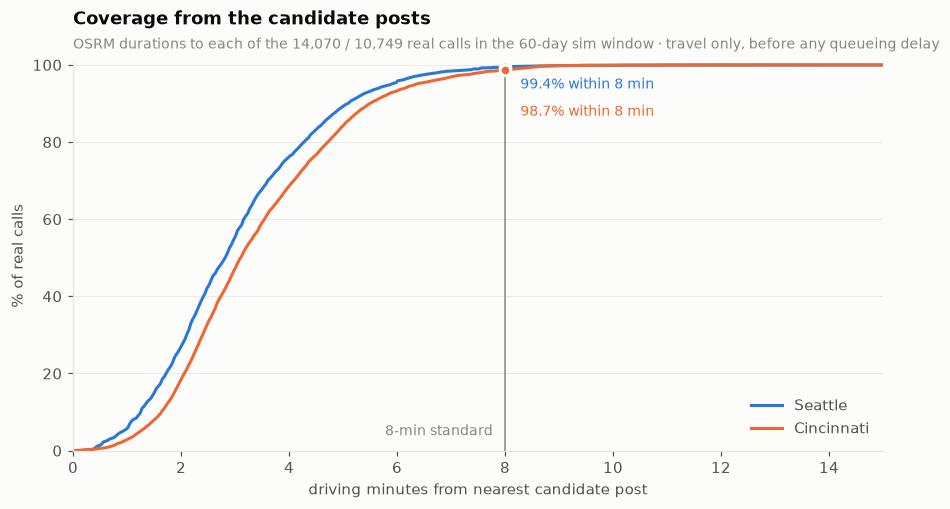

In [10]:
# Coverage curve: share of real calls within t driving-minutes of the nearest post.
fig, ax = plt.subplots(figsize=(9.5, 4.6))
t = np.linspace(0, 15, 400)
for (name, zc, color, dy) in [("Seattle", zc_sea, CAT[0], -14), ("Cincinnati", zc_cin, CAT[1], -30)]:
    nearest = zc.min(axis=0)
    share = (nearest[None, :] <= t[:, None]).mean(axis=1) * 100
    ax.plot(t, share, color=color, label=name)
    at8 = (nearest <= RESPONSE_STANDARD_MIN).mean() * 100
    ax.scatter([RESPONSE_STANDARD_MIN], [at8], s=48, color=color,
               edgecolors=P["surface"], linewidths=2, zorder=3)
    ax.annotate(f"{at8:.1f}% within {RESPONSE_STANDARD_MIN} min",
                (RESPONSE_STANDARD_MIN, at8), xytext=(10, dy),
                textcoords="offset points", color=color, fontsize=9)
ax.axvline(RESPONSE_STANDARD_MIN, color=P["ink3"], linewidth=1)
ax.annotate(f"{RESPONSE_STANDARD_MIN}-min standard", (RESPONSE_STANDARD_MIN, 4),
            xytext=(-8, 0), textcoords="offset points", ha="right",
            color=P["ink3"], fontsize=9)
ax.set_xlim(0, 15); ax.set_ylim(0, 101)
ax.set_xlabel("driving minutes from nearest candidate post"); ax.set_ylabel("% of real calls")
ax.legend(loc="lower right", labelcolor=P["ink2"])
finish(ax, "Coverage from the candidate posts",
       f"OSRM durations to each of the {zc_sea.shape[1]:,} / {zc_cin.shape[1]:,} real calls in "
       "the 60-day sim window · travel only, before any queueing delay")
plt.show()

## 5 · The compliance table

Daskin's greedy MEXCLP ranks the candidate posts by *expected* marginal coverage,
discounting each additional coverer by the empirical busy fraction `q`. The ranking
is not simply "busiest zone first" — a zone already covered by a higher-ranked post
contributes little, so the greedy pass spreads out.

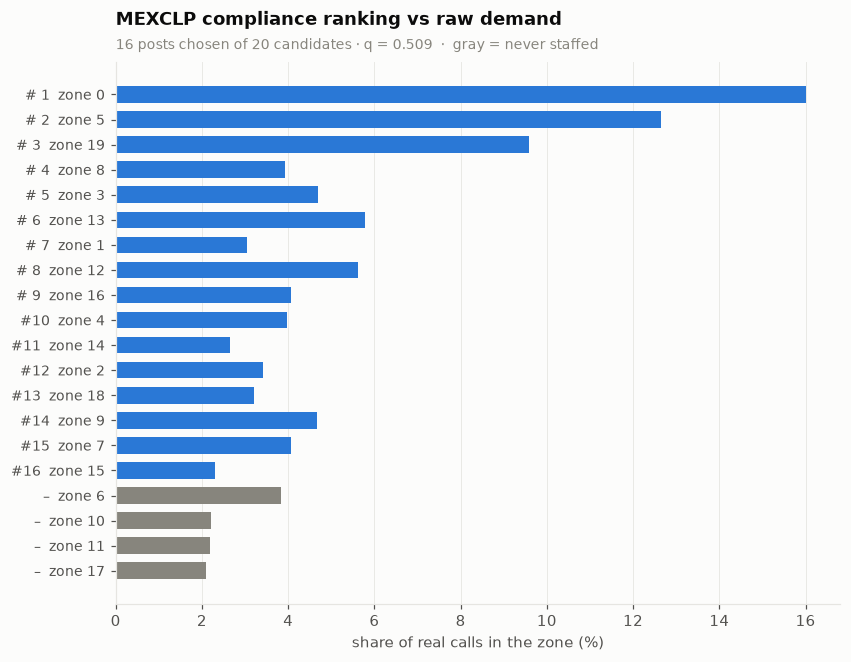

In [11]:
zone_w = np.array([z["weight"] for z in sim_sea["all_zone_centers"]])
zone_xy = np.array([[z["lat"], z["lng"]] for z in sim_sea["all_zone_centers"]])
table = sim_sea["compliance_table"]

# Two states of one thing (chosen / not chosen), so a single hue plus a recessive gray.
order = table + [z for z in range(len(zone_w)) if z not in table]
vals = zone_w[order] * 100
colors = [CAT[0] if z in table else P["ink3"] for z in order]
labels = [f"#{table.index(z)+1:>2}  zone {z}" if z in table else f"  –  zone {z}" for z in order]

fig, ax = plt.subplots(figsize=(8.5, 6.4))
ax.barh(range(len(order))[::-1], vals, color=colors, height=0.66)
ax.set_yticks(range(len(order))[::-1], labels, fontsize=9)
ax.set_xlabel("share of real calls in the zone (%)")
finish(ax, "MEXCLP compliance ranking vs raw demand",
       f"{len(table)} posts chosen of {len(zone_w)} candidates · "
       f"q = {sim_sea['busy_fraction_q']}  ·  gray = never staffed", grid="x")
plt.show()

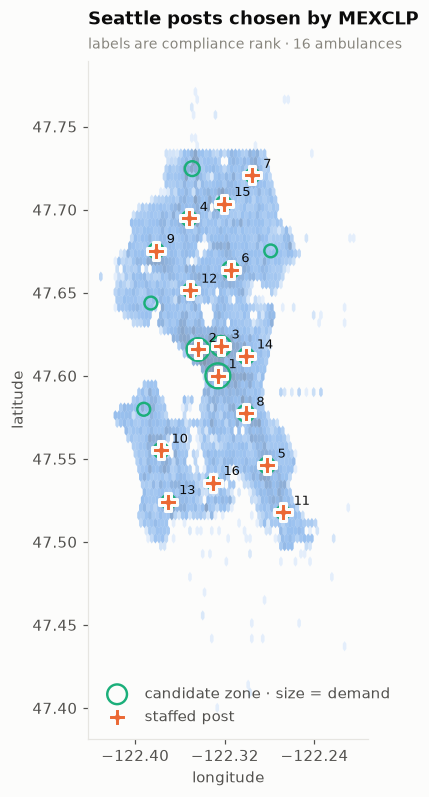

In [12]:
# Map: real calls as recessive density, model output on top. Three cat slots max.
homes = np.array([[h["lat"], h["lng"]] for h in sim_sea["home_bases"]])

fig, ax = plt.subplots(figsize=(6.8, 8))
ax.hexbin(sea["longitude"], sea["latitude"], gridsize=70, cmap=SEQ, bins="log",
          mincnt=1, linewidths=0, alpha=0.5)
ax.scatter(zone_xy[:, 1], zone_xy[:, 0], s=40 + zone_w * 1400, marker="o",
           facecolors="none", edgecolors=CAT[2], linewidths=1.6, zorder=3,
           label="candidate zone · size = demand")
ax.scatter(homes[:, 1], homes[:, 0], s=130, marker="P", color=CAT[1],
           edgecolors=P["surface"], linewidths=2, zorder=4, label="staffed post")
for rank, z in enumerate(table, 1):
    ax.annotate(str(rank), (zone_xy[z, 1], zone_xy[z, 0]), xytext=(7, 5),
                textcoords="offset points", color=P["ink"], fontsize=8.5, zorder=5)
ax.set_aspect(1 / np.cos(np.radians(47.6)))
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.legend(loc="lower left", labelcolor=P["ink2"])
finish(ax, "Seattle posts chosen by MEXCLP",
       f"labels are compliance rank · {sim_sea['n_ambulances']} ambulances", grid=None)
plt.show()

## 6 · Static vs dynamic, 60 real days

Two strategies over the identical real call stream, same arrivals, same service-time
draws. **Static:** each unit owns a post and returns to it. **Dynamic:** idle units
continuously re-fill the top of the compliance table as availability changes.

In [13]:
metrics = ["avg", "median", "p90"]
res = pd.DataFrame({
    (city, strat): [sim[f"{m}_response_min_{strat}"] for m in metrics]
    for city, sim in [("Seattle", sim_sea), ("Cincinnati", sim_cin)]
    for strat in ["static", "dynamic"]
}, index=[m + " response (min)" for m in metrics])
res.round(2)

Seattle         Cincinnati        
                       static dynamic     static dynamic
avg response (min)      15.26   12.59       4.41    3.71
median response (min)    9.51    6.83       3.92    3.43
p90 response (min)      35.29   31.19       7.71    5.97

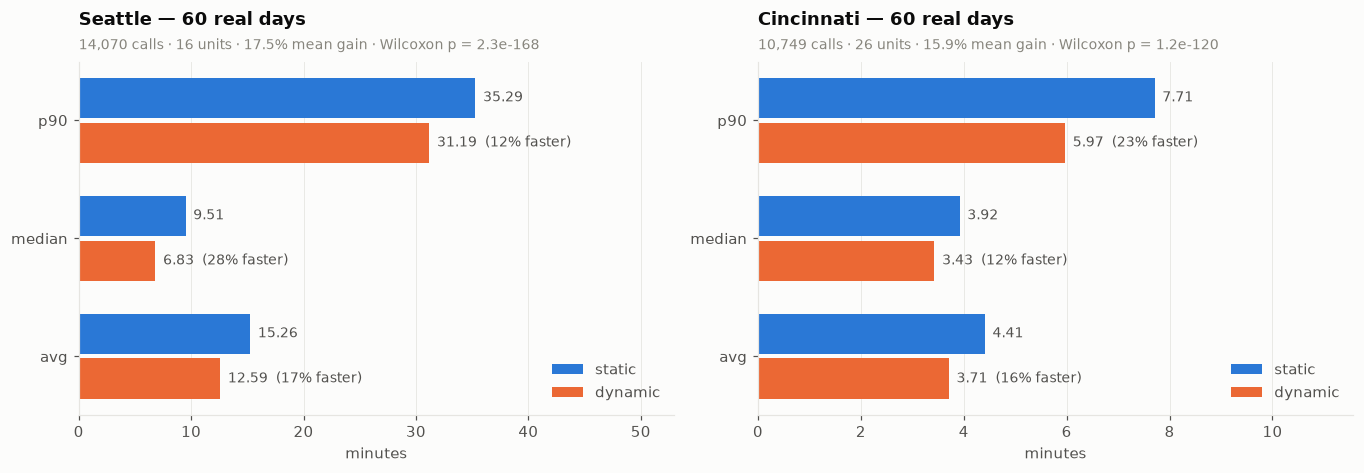

In [14]:
# Same quantity twice under two policies => two categorical slots, one shared axis.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
y = np.arange(len(metrics))
for ax, (city, sim) in zip(axes, [("Seattle", sim_sea), ("Cincinnati", sim_cin)]):
    stat = [sim[f"{m}_response_min_static"] for m in metrics]
    dyn = [sim[f"{m}_response_min_dynamic"] for m in metrics]
    ax.barh(y + 0.19, stat, height=0.34, color=CAT[0], label="static")
    ax.barh(y - 0.19, dyn, height=0.34, color=CAT[1], label="dynamic")
    for i, (s, d) in enumerate(zip(stat, dyn)):
        ax.annotate(f"{s:.2f}", (s, i + 0.19), xytext=(5, 0), textcoords="offset points",
                    va="center", color=P["ink2"], fontsize=9)
        ax.annotate(f"{d:.2f}  ({(s-d)/s:.0%} faster)", (d, i - 0.19), xytext=(5, 0),
                    textcoords="offset points", va="center", color=P["ink2"], fontsize=9)
    ax.set_yticks(y, metrics)
    ax.set_xlim(0, max(stat) * 1.5)
    ax.set_xlabel("minutes")
    ax.legend(loc="lower right", labelcolor=P["ink2"])
    p = sim["wilcoxon_p_value"]
    finish(ax, f"{city} — {sim['sim_days']} real days",
           f"{sim['n_calls']:,} calls · {sim['n_ambulances']} units · "
           f"{sim['pct_improvement']}% mean gain · Wilcoxon p = {p:.1e}", grid="x")
plt.tight_layout()
plt.show()

## 7 · One day, call by call

`sim_trace_seattle.json` records every dispatch on a single simulated day under both
strategies — same 281 real calls, same arrival times. This is where the mechanism is
visible: the gain comes from queueing, not from shaving travel time.

In [15]:
st = pd.DataFrame(trace["static_events"]).assign(t=lambda d: pd.to_datetime(d["t"]))
dy = pd.DataFrame(trace["dynamic_events"]).assign(t=lambda d: pd.to_datetime(d["t"]))
day = pd.DataFrame({
    "t": st["t"], "hour": st["t"].dt.hour + st["t"].dt.minute / 60,
    "static": st["response_min"], "dynamic": dy["response_min"],
    "static_wait": st["wait_min"], "dynamic_wait": dy["wait_min"],
    "static_travel": st["travel_min"], "dynamic_travel": dy["travel_min"],
})
day["delta"] = day["dynamic"] - day["static"]
print(f"{trace['date']} · {trace['n_calls']} calls · {trace['n_ambulances']} units")
print(day[["static", "dynamic", "static_wait", "dynamic_wait",
           "static_travel", "dynamic_travel"]].mean().round(2).to_string())

2026-06-18 · 281 calls · 16 units
static            24.57
dynamic           22.60
static_wait       13.99
dynamic_wait      12.61
static_travel     10.58
dynamic_travel     9.99


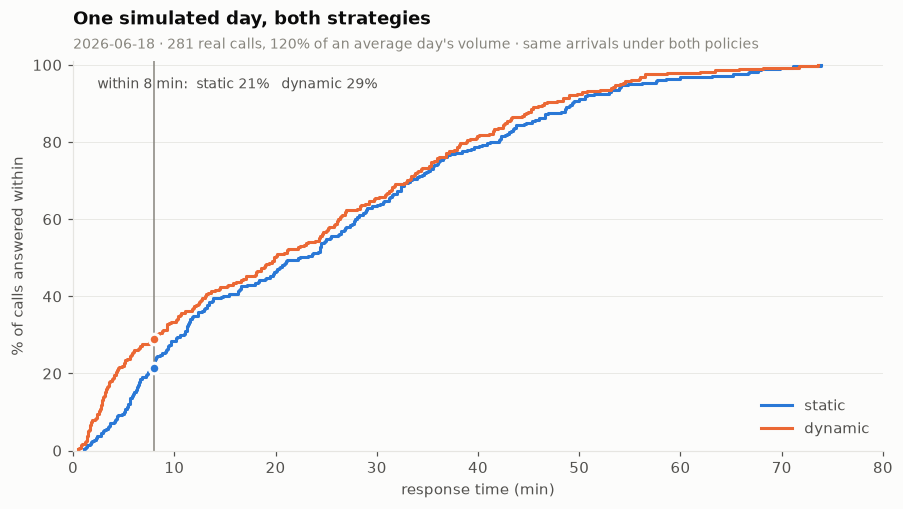

In [16]:
# "Answered within t" - the shape a service level is actually written against.
fig, ax = plt.subplots(figsize=(9.5, 4.6))
at8 = {}
for col, color in [("static", CAT[0]), ("dynamic", CAT[1])]:
    v = np.sort(day[col].to_numpy())
    ax.step(v, np.arange(1, len(v) + 1) / len(v) * 100, where="post", color=color, label=col)
    at8[col] = (day[col] <= RESPONSE_STANDARD_MIN).mean() * 100
    ax.scatter([RESPONSE_STANDARD_MIN], [at8[col]], s=48, color=color,
               edgecolors=P["surface"], linewidths=2, zorder=3)
ax.axvline(RESPONSE_STANDARD_MIN, color=P["ink3"], linewidth=1)
ax.annotate(f"within {RESPONSE_STANDARD_MIN} min:  static {at8['static']:.0f}%   "
            f"dynamic {at8['dynamic']:.0f}%",
            xy=(0.03, 0.93), xycoords="axes fraction", color=P["ink2"], fontsize=9)
ax.set_xlim(0, 80); ax.set_ylim(0, 101)
ax.set_xlabel("response time (min)"); ax.set_ylabel("% of calls answered within")
ax.legend(loc="lower right", labelcolor=P["ink2"])
busy = trace["n_calls"] / (sim_sea["n_calls"] / sim_sea["sim_days"])
finish(ax, "One simulated day, both strategies",
       f"{trace['date']} · {trace['n_calls']} real calls, {busy:.0%} of an average day's "
       "volume · same arrivals under both policies")
plt.show()

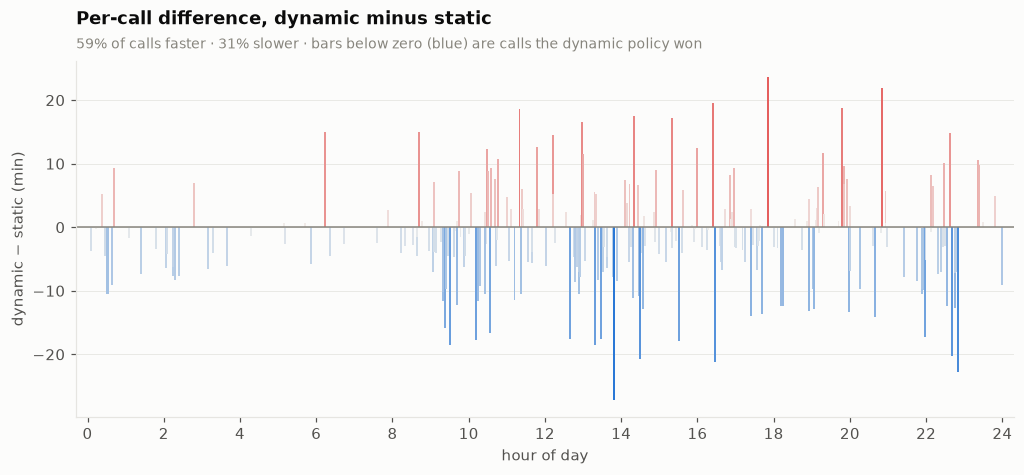

In [17]:
# Polarity per call (faster / slower) => diverging ramp, gray at zero.
lim = np.abs(day["delta"]).max()
norm = mpl.colors.Normalize(-lim, lim)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(day["hour"], day["delta"], width=0.05, color=DIV(norm(day["delta"])), linewidth=0)
ax.axhline(0, color=P["ink3"], linewidth=1)
ax.set_xticks(range(0, 25, 2))
ax.set_xlim(-0.3, 24.3)
ax.set_xlabel("hour of day"); ax.set_ylabel("dynamic − static (min)")
better = (day["delta"] < -0.01).mean()
worse = (day["delta"] > 0.01).mean()
finish(ax, "Per-call difference, dynamic minus static",
       f"{better:.0%} of calls faster · {worse:.0%} slower · "
       f"bars below zero (blue) are calls the dynamic policy won")
plt.show()

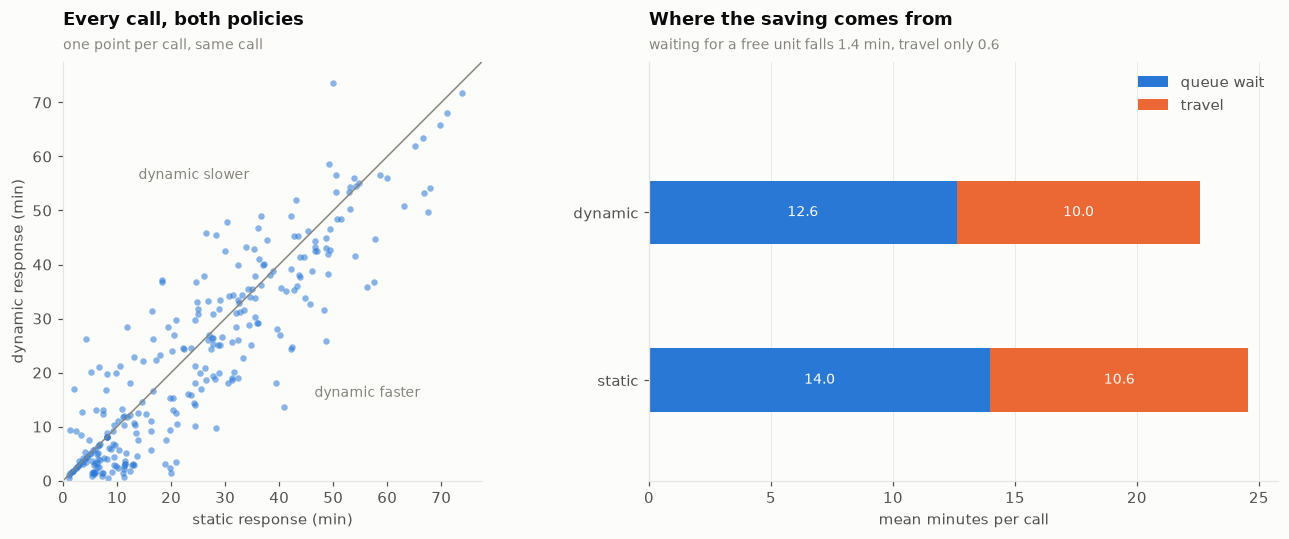

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))

# Paired, so plot the pairs. Points under the line are calls the dynamic policy won.
ax = axes[0]
hi = max(day["static"].max(), day["dynamic"].max()) * 1.05
ax.plot([0, hi], [0, hi], color=P["ink3"], linewidth=1)
ax.scatter(day["static"], day["dynamic"], s=18, color=CAT[0], alpha=0.55, linewidths=0)
ax.annotate("dynamic slower", (hi * 0.18, hi * 0.72), color=P["ink3"], fontsize=9)
ax.annotate("dynamic faster", (hi * 0.60, hi * 0.20), color=P["ink3"], fontsize=9)
ax.set_xlim(0, hi); ax.set_ylim(0, hi); ax.set_aspect("equal")
ax.set_xlabel("static response (min)"); ax.set_ylabel("dynamic response (min)")
finish(ax, "Every call, both policies", "one point per call, same call", grid=None)

# Where the minutes actually come from.
ax = axes[1]
parts = pd.DataFrame({
    "queue wait": [day["static_wait"].mean(), day["dynamic_wait"].mean()],
    "travel": [day["static_travel"].mean(), day["dynamic_travel"].mean()],
}, index=["static", "dynamic"])
left = np.zeros(2)
for (name, color) in [("queue wait", CAT[0]), ("travel", CAT[1])]:
    ax.barh(parts.index, parts[name], left=left, height=0.38, color=color, label=name)
    for i, v in enumerate(parts[name]):
        ax.annotate(f"{v:.1f}", (left[i] + v / 2, i), ha="center", va="center",
                    color=P["surface"], fontsize=9)
    left += parts[name].to_numpy()
ax.set_ylim(-0.6, 1.9)
ax.set_xlabel("mean minutes per call")
ax.legend(loc="upper right", labelcolor=P["ink2"])
dw = parts.loc["static", "queue wait"] - parts.loc["dynamic", "queue wait"]
dt = parts.loc["static", "travel"] - parts.loc["dynamic", "travel"]
finish(ax, "Where the saving comes from",
       f"waiting for a free unit falls {dw:.1f} min, travel only {dt:.1f}", grid="x")

plt.tight_layout()
plt.show()

## 8 · Realism check against measured times

Cincinnati is the only feed in the repo with real arrival timestamps, so it is the
only place the simulated distribution can be checked against reality.

This is **not** a causal comparison. The measured numbers come from the actual
fielded fleet and dispatch policy; the simulated numbers assume a hypothetical
26-unit fleet on MEXCLP posts. The question is only whether the simulator lands in
a plausible range for a real mid-size city.

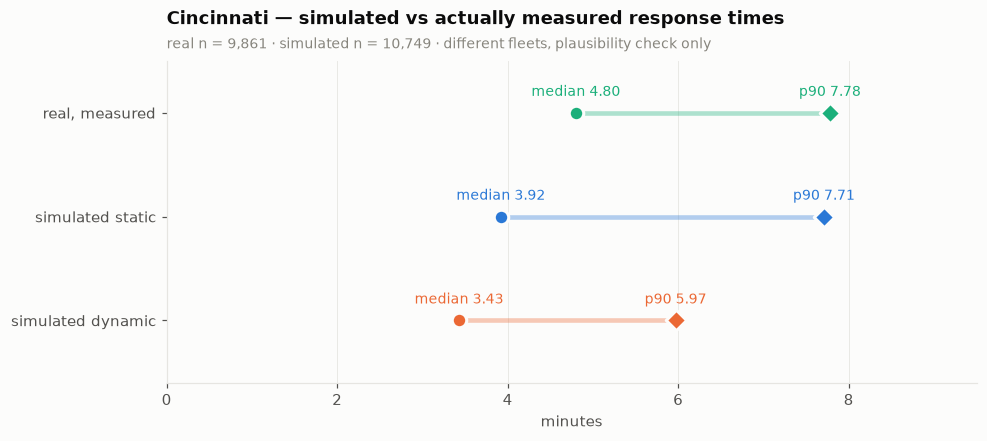

Real Cincinnati Fire Dept response times are for the ACTUAL fielded fleet/dispatch policy; simulated static/dynamic figures assume a hypothetical N_AMBULANCES-truck fleet at MEXCLP-chosen posts. This is a realism check (is the simulated distribution in a plausible range for a real mid-size city), NOT a real-vs-model causal comparison -- real fleet size/positions are unknown from this CAD export.


In [19]:
rows = [
    ("real, measured", sim_cin["REAL_measured_response_min_median"],
     sim_cin["REAL_measured_response_min_p90"], CAT[2]),
    ("simulated static", sim_cin["median_response_min_static"],
     sim_cin["p90_response_min_static"], CAT[0]),
    ("simulated dynamic", sim_cin["median_response_min_dynamic"],
     sim_cin["p90_response_min_dynamic"], CAT[1]),
]

fig, ax = plt.subplots(figsize=(9.5, 3.8))
for i, (name, med, p90, color) in enumerate(rows):
    y = len(rows) - 1 - i
    ax.plot([med, p90], [y, y], color=color, linewidth=3, solid_capstyle="round", alpha=0.35)
    ax.scatter([med], [y], s=90, color=color, edgecolors=P["surface"], linewidths=2, zorder=3)
    ax.scatter([p90], [y], s=90, marker="D", color=color,
               edgecolors=P["surface"], linewidths=2, zorder=3)
    ax.annotate(f"median {med:.2f}", (med, y), xytext=(0, 11), textcoords="offset points",
                ha="center", color=color, fontsize=9)
    ax.annotate(f"p90 {p90:.2f}", (p90, y), xytext=(0, 11), textcoords="offset points",
                ha="center", color=color, fontsize=9)
ax.set_yticks(range(len(rows))[::-1], [r[0] for r in rows])
ax.set_xlim(0, 9.5); ax.set_ylim(-0.6, 2.5)
ax.set_xlabel("minutes")
finish(ax, "Cincinnati — simulated vs actually measured response times",
       f"real n = {sim_cin['REAL_measured_n']:,} · simulated n = {sim_cin['n_calls']:,} · "
       "different fleets, plausibility check only", grid="x")
plt.show()

print(sim_cin["REAL_vs_SIM_note"])

## 9 · Hourly demand forecast

Separate model, separate job: how many units should be active *right now*, not where
to put them. It forecasts citywide volume per hour, deliberately not per-zone — §10
is the reason why.

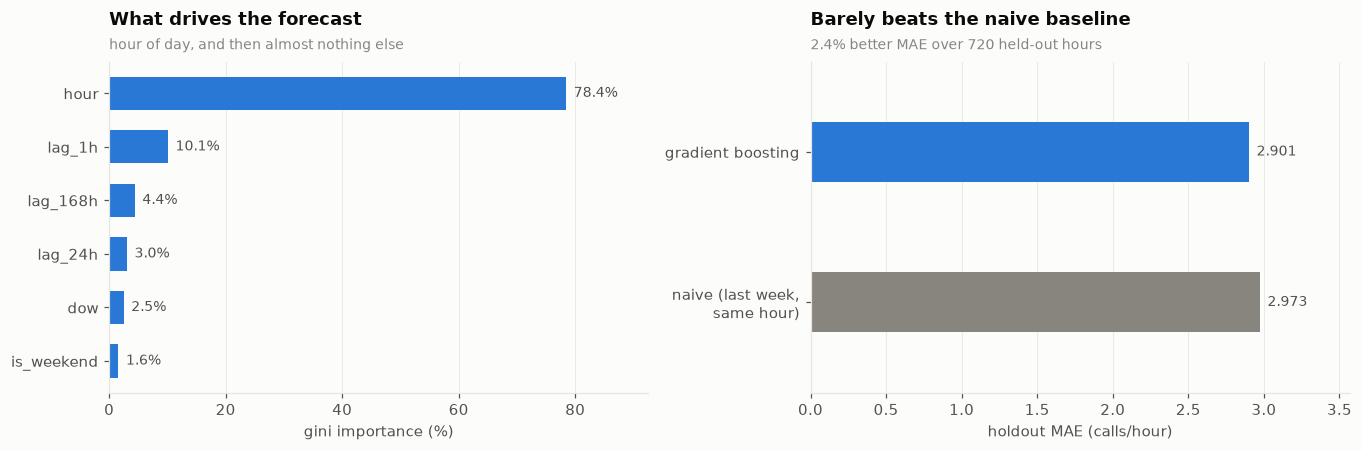

In [20]:
fi = pd.Series(forecast["feature_importances"]).sort_values()
hm = forecast["holdout_metrics"]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

ax = axes[0]
ax.barh(fi.index, fi.values * 100, color=CAT[0], height=0.62)
ax.bar_label(ax.containers[0], labels=[f"{v*100:.1f}%" for v in fi.values],
             padding=5, color=P["ink2"], fontsize=9)
ax.set_xlim(0, fi.max() * 118)
ax.set_xlabel("gini importance (%)")
finish(ax, "What drives the forecast", "hour of day, and then almost nothing else", grid="x")

ax = axes[1]
bars = pd.Series({"naive (last week,\nsame hour)": hm["naive_baseline_mae"],
                  "gradient boosting": hm["model_mae"]})
ax.barh(bars.index, bars.values, color=[P["ink3"], CAT[0]], height=0.4)
ax.set_ylim(-0.6, 1.6)
ax.bar_label(ax.containers[0], labels=[f"{v:.3f}" for v in bars.values],
             padding=5, color=P["ink2"], fontsize=9)
ax.set_xlim(0, bars.max() * 1.2)
ax.set_xlabel("holdout MAE (calls/hour)")
finish(ax, "Barely beats the naive baseline",
       f"{hm['mae_improvement_pct_vs_naive']}% better MAE over "
       f"{forecast['n_test_hours']:,} held-out hours", grid="x")

plt.tight_layout()
plt.show()

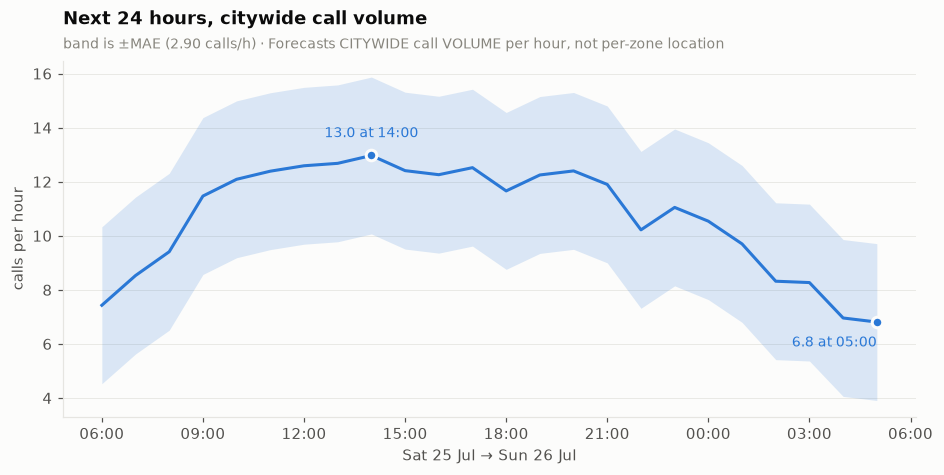

In [21]:
fc = pd.DataFrame(forecast["next_24h_forecast"])
fc["datetime"] = pd.to_datetime(fc["datetime"])
mae = hm["model_mae"]

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.fill_between(fc["datetime"], fc["predicted_calls"] - mae, fc["predicted_calls"] + mae,
                color=CAT[0], alpha=0.16, linewidth=0)
ax.plot(fc["datetime"], fc["predicted_calls"], color=CAT[0])
hi = fc["predicted_calls"].idxmax(); lo = fc["predicted_calls"].idxmin()
for i, va, ha in [(hi, 12, "center"), (lo, -16, "right")]:
    ax.scatter([fc.datetime[i]], [fc.predicted_calls[i]], s=48, color=CAT[0],
               edgecolors=P["surface"], linewidths=2, zorder=3)
    ax.annotate(f"{fc.predicted_calls[i]:.1f} at {fc.datetime[i]:%H:%M}",
                (fc.datetime[i], fc.predicted_calls[i]), xytext=(0, va),
                textcoords="offset points", ha=ha, color=CAT[0], fontsize=9)
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%H:%M"))
ax.set_xlabel(f"{fc.datetime.min():%a %d %b} → {fc.datetime.max():%a %d %b}")
ax.set_ylabel("calls per hour")
finish(ax, "Next 24 hours, citywide call volume",
       f"band is ±MAE ({mae:.2f} calls/h) · {forecast['disclosed_scope'].split('--')[0].strip()}")
plt.show()

## 10 · The dead end, kept in the record

Before the queueing simulation, the approach was a static schedule: pick the best
N-of-K zones *per time bucket* and move units on the clock. Brute-force optimal
subset selection, so the result is a ceiling — no heuristic can beat it.

It gained nothing. In Montgomery County the optimal subset was identical in all 18
buckets. In Seattle a few buckets pick a different zone, and the improvement is
still ~0. The busy zones are the busy zones all day; only *volume* moves by hour,
which is exactly what §9 forecasts and §6–7 react to instead.

In [22]:
def bucket_frame(model):
    zc = np.array([[z["lat"], z["lng"]] for z in model["all_zone_centers"]])
    base = {int(np.argmin(((zc - np.array([p["lat"], p["lng"]])) ** 2).sum(1))): None
            for p in model["static_baseline_posts"]}
    rows = []
    for name, b in model["buckets"].items():
        rows.append({
            "bucket": name, "n_calls": b["n_calls"],
            "posts_changed": len(set(b["zone_ids"]) - set(base)),
            "delta_mi": b["avg_dist_recommended_mi"] - b["avg_dist_baseline_mi"],
        })
    return pd.DataFrame(rows).set_index("bucket")


bk = {"Montgomery County": bucket_frame(reloc_montco), "Seattle": bucket_frame(reloc_sea)}
summary = pd.DataFrame({
    city: {
        "calls used": m["n_calls_used"],
        "zones / posts": f"{m['k_zones']} / {m['n_posts']}",
        "improvement %": m["pct_improvement_overall"],
        "minutes saved": m["minutes_saved"],
        "Wilcoxon p": m["wilcoxon_p_value"],
        "buckets that swap a post": int((bk[city]["posts_changed"] > 0).sum()),
    }
    for city, m in [("Montgomery County", reloc_montco), ("Seattle", reloc_sea)]
}).T
summary

,calls used,zones / posts,improvement %,minutes saved,Wilcoxon p,buckets that swap a post
Montgomery County,332208,14 / 5,0.0,0.0,NaN,0
Seattle,380604,20 / 5,0.0,0.0,0.119694,1


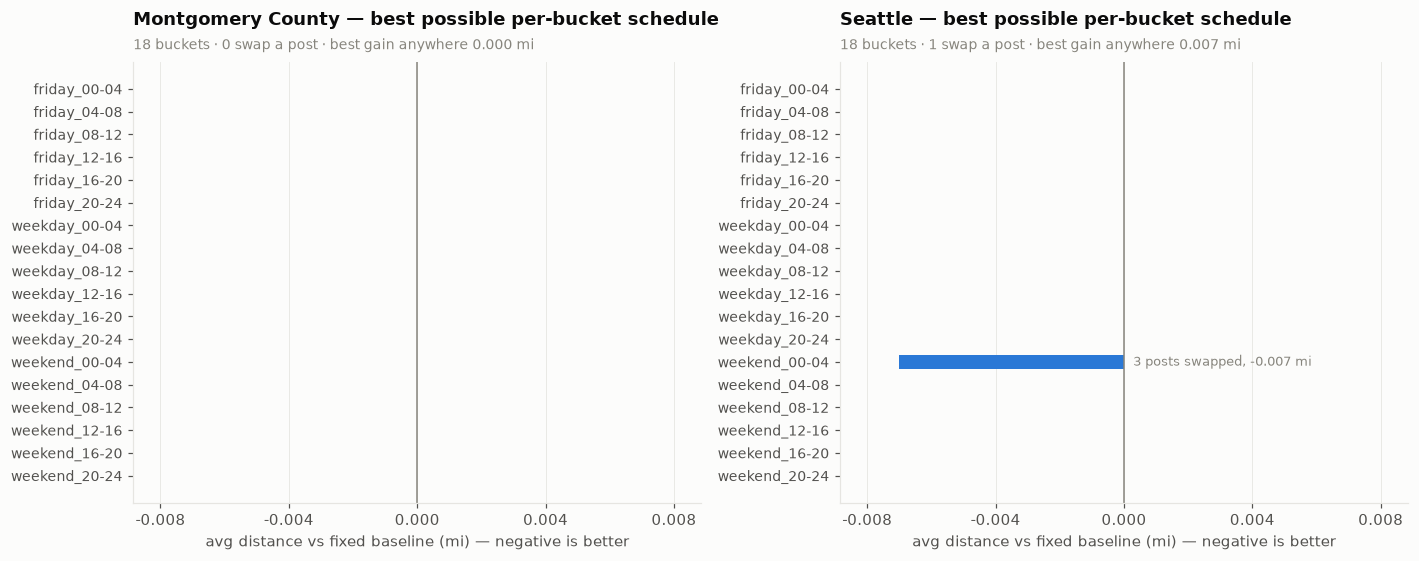

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharex=True)
lim = max(np.abs(f["delta_mi"]).max() for f in bk.values()) or 0.01
norm = mpl.colors.Normalize(-lim, lim)

for ax, (city, f) in zip(axes, bk.items()):
    ax.barh(f.index[::-1], f["delta_mi"][::-1],
            color=DIV(norm(f["delta_mi"][::-1])), height=0.62)
    ax.axvline(0, color=P["ink3"], linewidth=1)
    swaps = int((f["posts_changed"] > 0).sum())
    for i, (name, r) in enumerate(f[::-1].iterrows()):
        n = int(r["posts_changed"])
        if n:
            ax.annotate(f"{n} post{'s' if n > 1 else ''} swapped, {r['delta_mi']:+.3f} mi",
                        (0, i), xytext=(6, 0), textcoords="offset points",
                        va="center", color=P["ink3"], fontsize=8.5)
    ax.set_xlim(-lim * 1.25 - 1e-4, lim * 1.25 + 1e-4)
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(5))
    ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.3f"))
    ax.set_xlabel("avg distance vs fixed baseline (mi) — negative is better")
    ax.tick_params(axis="y", labelsize=9)
    best = f["delta_mi"].min()
    finish(ax, f"{city} — best possible per-bucket schedule",
           f"{len(f)} buckets · {swaps} swap a post · best gain anywhere {abs(best):.3f} mi",
           grid="x")

plt.tight_layout()
plt.show()

### Summary

- Two real call feeds, Seattle (500k-row pull, EMS-relevant types) and Cincinnati
  (60-day CAD window), with near-identical hourly demand shapes.
- Travel is real OSRM road-network driving time throughout; the candidate posts put
  the large majority of real calls within the 8-minute standard on travel alone.
- Over 60 real days, compliance-table restaging beats static posting in both cities
  — Seattle 15.26 → 12.59 min mean, Cincinnati 4.41 → 3.71 — on paired call streams,
  Wilcoxon p far below any threshold worth quoting.
- The one-day trace shows why: the saving is in queue wait, not travel. Dynamic
  keeps a unit near the next gap, so fewer calls wait for a busy fleet.
- Cincinnati's measured median (4.8 min) and p90 (7.78 min) put the simulated
  distribution in a plausible real-city range — a sanity check, not a validation.
- The static per-bucket schedule remains a documented dead end. Its ceiling is zero.

**Still assumed:** per-call unit-busy time (lognormal, 50 min). Everything else in
these plots is measured or derived from measured data. Real service-time
distributions from a CAD export would remove the last assumption.